<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

print(f"PyTorch Versiyon: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

PyTorch Versiyon: 2.10.0+cu128
Kullanılan Cihaz: cuda
GPU Model: NVIDIA A100-SXM4-40GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
import datetime

# Benzersiz deney adı oluştur (Tarih ve Saat ile)
zaman_damgasi = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
deney_adi = f"Deney_{zaman_damgasi}"

CONFIG = {
    "kaynak_CN"   : '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slicee/Slice_CN',
    "kaynak_EMCI" : '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slicee/Slice_EMCI',
    "model_kayit" : f'/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/{deney_adi}',
    "k_fold"      : 5,
    "batch_size"  : 16,
    "epoch"       : 50,
    "lr"          : 1e-4,
    "img_size"    : 224,
    "patience"    : 10
}

# Drive'da bu deney için özel klasör aç
os.makedirs(CONFIG["model_kayit"], exist_ok=True)
print(f"✅ Deney Klasörü Oluşturuldu: {CONFIG['model_kayit']}")

✅ Deney Klasörü Oluşturuldu: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/Deney_2026_04_26_16_26


In [9]:
def veri_listesi_olustur(config):
    data_list = [] # [(hasta_id, seans_id, etiket, [kesit_yollari]), ...]

    for etiket_adi, ana_yol, etiket_val in [("CN", config["kaynak_CN"], 0), ("EMCI", config["kaynak_EMCI"], 1)]:
        hastalar = sorted([d for d in os.listdir(ana_yol) if os.path.isdir(os.path.join(ana_yol, d))])
        for h_id in hastalar:
            h_yolu = os.path.join(ana_yol, h_id)
            seanslar = sorted([s for s in os.listdir(h_yolu) if os.path.isdir(os.path.join(h_yolu, s))])
            for s_id in seanslar:
                s_yolu = os.path.join(h_yolu, s_id)
                kesitler = sorted([os.path.join(s_yolu, f) for f in os.listdir(s_yolu) if f.endswith('.nii.gz')])
                if len(kesitler) == 15: # Sadece tam olan seansları al
                    data_list.append({
                        "hasta_id": h_id,
                        "seans_id": s_id,
                        "etiket": etiket_val,
                        "kesitler": kesitler
                    })

    print(f"📊 Toplam Seans (Görüntü) Sayısı: {len(data_list)}")
    print(f"   - CN Seans: {sum(1 for x in data_list if x['etiket'] == 0)}")
    print(f"   - EMCI Seans: {sum(1 for x in data_list if x['etiket'] == 1)}")
    return data_list

tum_veriler = veri_listesi_olustur(CONFIG)

📊 Toplam Seans (Görüntü) Sayısı: 477
   - CN Seans: 266
   - EMCI Seans: 211


In [10]:
import pandas as pd

def fold_analizi_kaydet(veriler, config):
    unique_patient_ids = sorted(list(set([x['hasta_id'] for x in veriler])))
    kf = KFold(n_splits=config["k_fold"], shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(kf.split(unique_patient_ids), 1):
        tr_ids = [unique_patient_ids[i] for i in train_idx]
        te_ids = [unique_patient_ids[i] for i in test_idx]

        # CSV Dosyası Hazırla (Hem Train hem Test listesini tutalım)
        df_dagilim = pd.DataFrame({
            'hasta_id': tr_ids + te_ids,
            'rol': ['train']*len(tr_ids) + ['test']*len(te_ids)
        })

        # Drive'a kaydet: fold_1_dagilim.csv vb.
        csv_adi = f"fold_{fold}_hasta_dagilimi.csv"
        df_dagilim.to_csv(os.path.join(config["model_kayit"], csv_adi), index=False)

        print(f"📁 FOLD {fold}:")
        print(f"   🟢 Train: {len(tr_ids)} Hasta | 🔴 Test: {len(te_ids)} Hasta")
        print(f"   ✅ Liste Drive'a kaydedildi: {csv_adi}\n")

fold_analizi_kaydet(tum_veriler, CONFIG)

📁 FOLD 1:
   🟢 Train: 160 Hasta | 🔴 Test: 40 Hasta
   ✅ Liste Drive'a kaydedildi: fold_1_hasta_dagilimi.csv

📁 FOLD 2:
   🟢 Train: 160 Hasta | 🔴 Test: 40 Hasta
   ✅ Liste Drive'a kaydedildi: fold_2_hasta_dagilimi.csv

📁 FOLD 3:
   🟢 Train: 160 Hasta | 🔴 Test: 40 Hasta
   ✅ Liste Drive'a kaydedildi: fold_3_hasta_dagilimi.csv

📁 FOLD 4:
   🟢 Train: 160 Hasta | 🔴 Test: 40 Hasta
   ✅ Liste Drive'a kaydedildi: fold_4_hasta_dagilimi.csv

📁 FOLD 5:
   🟢 Train: 160 Hasta | 🔴 Test: 40 Hasta
   ✅ Liste Drive'a kaydedildi: fold_5_hasta_dagilimi.csv



In [11]:
class MRIDataset(Dataset):
    def __init__(self, seans_listesi, img_size=224):
        self.ornekler = []
        for s in seans_listesi:
            for k_yolu in s["kesitler"]:
                self.ornekler.append({
                    "seans_id": f"{s['hasta_id']}_{s['seans_id']}",
                    "yol": k_yolu,
                    "etiket": s["etiket"]
                })

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.ornekler)

    def __getitem__(self, idx):
        item = self.ornekler[idx]
        img = nib.load(item["yol"]).get_fdata().astype(np.float32)
        # 2D kesiti 3 kanala kopyala (ResNet için)
        img = np.stack([img.squeeze()]*3, axis=-1)
        return item["seans_id"], self.transform(img), torch.tensor(item["etiket"], dtype=torch.long)

In [12]:
def resnet50_ozellestir():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # İlk katmanları dondur, son iki bloğu eğitime aç
    for param in model.parameters(): param.requires_grad = False
    for param in model.layer3.parameters(): param.requires_grad = True
    for param in model.layer4.parameters(): param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2)
    )
    return model.to(DEVICE)

In [13]:
def seans_bazli_degerlendir(model, loader):
    model.eval()
    seans_sonuclar = {} # {seans_full_id: {'preds': [], 'truth': label}}

    with torch.no_grad():
        for s_ids, inputs, labels in loader:
            outputs = model(inputs.to(DEVICE))
            _, preds = torch.max(outputs, 1)

            for s_id, p, t in zip(s_ids, preds.cpu().numpy(), labels.numpy()):
                if s_id not in seans_sonuclar:
                    seans_sonuclar[s_id] = {'preds': [], 'truth': t}
                seans_sonuclar[s_id]['preds'].append(p)

    y_true, y_pred = [], []
    for s_id in seans_sonuclar:
        p_list = seans_sonuclar[s_id]['preds']
        final_p = 1 if sum(p_list) > len(p_list)/2 else 0
        y_true.append(seans_sonuclar[s_id]['truth'])
        y_pred.append(final_p)

    return y_true, y_pred

In [14]:
class EarlyStopping:
    def __init__(self, patience=10, path='best.pth'):
        self.patience, self.path, self.best_loss = patience, path, float('inf')
        self.counter, self.early_stop = 0, False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]



🔵 FOLD 1 BAŞLIYOR
   Epoch 01 | Kayıp: 0.5273 | Hasta Bazlı Val Acc: 0.6941
   Epoch 02 | Kayıp: 0.2396 | Hasta Bazlı Val Acc: 0.6824
   Epoch 03 | Kayıp: 0.1234 | Hasta Bazlı Val Acc: 0.7412
   Epoch 04 | Kayıp: 0.0777 | Hasta Bazlı Val Acc: 0.7176
   Epoch 05 | Kayıp: 0.0700 | Hasta Bazlı Val Acc: 0.6824
   Epoch 06 | Kayıp: 0.0532 | Hasta Bazlı Val Acc: 0.6824
   Epoch 07 | Kayıp: 0.0427 | Hasta Bazlı Val Acc: 0.6824
   Epoch 08 | Kayıp: 0.0561 | Hasta Bazlı Val Acc: 0.5765
   Epoch 09 | Kayıp: 0.0348 | Hasta Bazlı Val Acc: 0.6941
   Epoch 10 | Kayıp: 0.0261 | Hasta Bazlı Val Acc: 0.6235
   Epoch 11 | Kayıp: 0.0216 | Hasta Bazlı Val Acc: 0.6824
   Epoch 12 | Kayıp: 0.0282 | Hasta Bazlı Val Acc: 0.6824
   Epoch 13 | Kayıp: 0.0399 | Hasta Bazlı Val Acc: 0.6588
   🛑 Sabır tükendi, Fold 1 için eğitim durduruldu.


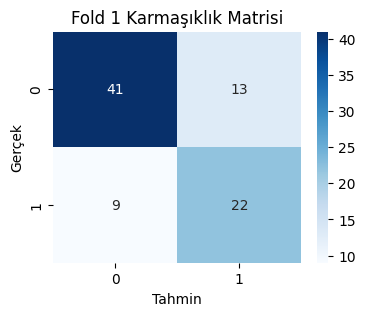

💾 Fold 1 sonuçları başarıyla Drive'a kaydedildi.

🔵 FOLD 2 BAŞLIYOR
   Epoch 01 | Kayıp: 0.5355 | Hasta Bazlı Val Acc: 0.7912


KeyboardInterrupt: 

In [15]:
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def egitimi_baslat_ve_yedekle(veriler, config):
    # Hasta bazlı bölme işlemi için benzersiz ID'leri al
    unique_pats = sorted(list(set([x['hasta_id'] for x in veriler])))
    kf = KFold(n_splits=config["k_fold"], shuffle=True, random_state=42)
    fold_results = []

    # Skorların kaydedileceği CSV yolu (Hücre 3'teki tarihli klasörün içi)
    csv_yolu = os.path.join(config["model_kayit"], "deney_sonuclari.csv")

    for fold, (train_idx, test_idx) in enumerate(kf.split(unique_pats), 1):
        # Bu fold için train ve test hastalarını ayır
        tr_ids = [unique_pats[i] for i in train_idx]
        te_ids = [unique_pats[i] for i in test_idx]

        tr_seans = [x for x in veriler if x['hasta_id'] in tr_ids]
        te_seans = [x for x in veriler if x['hasta_id'] in te_ids]

        # DataLoader'ları oluştur
        train_loader = DataLoader(MRIDataset(tr_seans), batch_size=config["batch_size"], shuffle=True)
        test_loader = DataLoader(MRIDataset(te_seans), batch_size=config["batch_size"], shuffle=False)

        # Modeli, Optimizasyonu ve Kayıp Fonksiyonunu hazırla
        model = resnet50_ozellestir()
        opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config["lr"])
        crit = nn.CrossEntropyLoss()

        # En iyi modelin kaydedileceği yol
        m_path = os.path.join(config["model_kayit"], f'resnet_fold_{fold}.pth')
        es = EarlyStopping(patience=config["patience"], path=m_path)

        print(f"\n{'='*50}\n🔵 FOLD {fold} BAŞLIYOR\n{'='*50}")

        for epoch in range(1, config["epoch"]+1):
            model.train()
            total_loss = 0
            for _, imgs, lbls in train_loader:
                opt.zero_grad()
                outputs = model(imgs.to(DEVICE))
                loss = crit(outputs, lbls.to(DEVICE))
                loss.backward()
                opt.step()
                total_loss += loss.item()

            # Epoch sonunda doğrulama yap (Seans/Hasta bazlı)
            y_t, y_p = seans_bazli_degerlendir(model, test_loader)
            acc = accuracy_score(y_t, y_p)

            print(f"   Epoch {epoch:02d} | Kayıp: {total_loss/len(train_loader):.4f} | Hasta Bazlı Val Acc: {acc:.4f}")

            # Erken durdurma kontrolü (En iyi model m_path'e kaydedilir)
            es(1-acc, model)
            if es.early_stop:
                print(f"   🛑 Sabır tükendi, Fold {fold} için eğitim durduruldu.")
                break

        # Eğitimi biten Fold'un en iyi ağırlıklarını yükle ve final testini yap
        model.load_state_dict(torch.load(m_path))
        y_t, y_p = seans_bazli_degerlendir(model, test_loader)

        # Confusion Matrix Çizimi
        plt.figure(figsize=(4,3))
        sns.heatmap(confusion_matrix(y_t, y_p), annot=True, fmt='d', cmap='Blues')
        plt.title(f"Fold {fold} Karmaşıklık Matrisi")
        plt.xlabel("Tahmin"); plt.ylabel("Gerçek")
        plt.show()

        # Metrikleri hesapla
        p, r, f, _ = precision_recall_fscore_support(y_t, y_p, average='weighted')

        # Fold sonucunu listeye ekle
        fold_skoru = {
            'fold': fold,
            'acc': accuracy_score(y_t, y_p),
            'prec': p,
            'rec': r,
            'f1': f
        }
        fold_results.append(fold_skoru)

        # SİGORTA: Her fold bittiğinde CSV'yi Drive'a güncelle
        pd.DataFrame(fold_results).to_csv(csv_yolu, index=False)
        print(f"💾 Fold {fold} sonuçları başarıyla Drive'a kaydedildi.")

    return fold_results

# Eğitimi başlat ve final listesini al
final_skorlar = egitimi_baslat_ve_yedekle(tum_veriler, CONFIG)

In [ ]:
import pandas as pd
import os

csv_yolu = os.path.join(CONFIG["model_kayit"], "final_metrikler.csv")

if os.path.exists(csv_yolu):
    df_sonuclar = pd.read_csv(csv_yolu)
    print(f"\n{'='*65}")
    print(f"📊 DRIVE'DAN YÜKLENEN FİNAL SONUÇLAR")
    print(f"{'='*65}")
    print(df_sonuclar.to_string(index=False)) # Tabloyu basar

    ortalamalar = df_sonuclar.mean()
    print(f"{'-'*65}")
    print(f"ORTALAMA | {ortalamalar['acc']:.4f} | {ortalamalar['prec']:.4f} | {ortalamalar['rec']:.4f} | {ortalamalar['f1']:.4f}")
    print(f"{'='*65}")
else:
    print("❌ Drive'da kayıtlı bir sonuç dosyası bulunamadı.")